# KFC Sales Data Analysis (Synthetic Dataset)

This notebook analyzes a simulated transactional dataset of ~96,700 KFC-style sales across 6 countries (Pakistan, USA, India, UK, UAE, Australia) from January to June 2025. The goal is to explore revenue patterns by country, menu item, channel, and time of day, and to statistically test whether observed differences between markets are meaningful.

**Note:** This is a synthetic/practice dataset, not real KFC corporate data.

In [1]:
import pandas as pd

In [2]:
df=pd.read_excel("kfc_sales_data.xlsx")

In [3]:
print(df.head())
print(df.shape)

  transaction_id        date day_of_week  hour        store_id country  \
0     TXN0000001  2025-01-01   Wednesday    20  KFC-USA-NYC-01     USA   
1     TXN0000002  2025-01-01   Wednesday    11  KFC-USA-NYC-01     USA   
2     TXN0000003  2025-01-01   Wednesday    12  KFC-USA-NYC-01     USA   
3     TXN0000004  2025-01-01   Wednesday    13  KFC-USA-NYC-01     USA   
4     TXN0000005  2025-01-01   Wednesday    13  KFC-USA-NYC-01     USA   

       city     channel       menu_item  items_count payment_method  \
0  New York  Drive-Thru  Combo/Multiple            4           Card   
1  New York    Takeaway  Combo/Multiple            5  Mobile Wallet   
2  New York    Delivery  Combo/Multiple            3           Cash   
3  New York    Delivery  Combo/Multiple            3           Cash   
4  New York  Drive-Thru  Combo/Multiple            5  Mobile Wallet   

   subtotal_usd  discount_usd  delivery_fee_usd  revenue_usd  
0          18.0          1.80              0.00        16.20  
1 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96738 entries, 0 to 96737
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    96738 non-null  object 
 1   date              96738 non-null  object 
 2   day_of_week       96738 non-null  object 
 3   hour              96738 non-null  int64  
 4   store_id          96738 non-null  object 
 5   country           96738 non-null  object 
 6   city              96738 non-null  object 
 7   channel           96738 non-null  object 
 8   menu_item         96738 non-null  object 
 9   items_count       96738 non-null  int64  
 10  payment_method    96738 non-null  object 
 11  subtotal_usd      96738 non-null  float64
 12  discount_usd      96738 non-null  float64
 13  delivery_fee_usd  96738 non-null  float64
 14  revenue_usd       96738 non-null  float64
dtypes: float64(4), int64(2), object(9)
memory usage: 11.1+ MB


In [5]:
df.describe()

,hour,items_count,subtotal_usd,discount_usd,delivery_fee_usd,revenue_usd
count,96738.000000,96738.000000,96738.000000,96738.000000,96738.000000,96738.000000
mean,15.943021,3.747535,22.563319,0.676978,0.399422,22.285763
std,3.524296,1.853937,16.795283,1.233304,0.841424,16.352703
min,11.000000,1.000000,1.500000,0.000000,0.000000,1.350000
25%,13.000000,2.000000,10.200000,0.000000,0.000000,10.350000
50%,16.000000,4.000000,18.500000,0.000000,0.000000,18.100000
75%,19.000000,5.000000,30.500000,0.950000,0.000000,30.000000
max,22.000000,8.000000,138.000000,13.200000,3.000000,138.000000


In [6]:
print(df['country'].value_counts())
print(df['city'].value_counts())
print(df['channel'].value_counts())
print(df['menu_item'].value_counts())
print(df['payment_method'].value_counts())

country
Pakistan     25909
USA          25430
India        15865
UK           12633
UAE           8840
Australia     8061
Name: count, dtype: int64
city
Delhi          15865
Karachi        14964
New York       13702
London         12633
Los Angeles    11728
Lahore         10945
Dubai           8840
Sydney          8061
Name: count, dtype: int64
channel
Dine-In       34144
Takeaway      23871
Drive-Thru    19458
Delivery      19265
Name: count, dtype: int64
menu_item
Combo/Multiple                   72498
Zinger Burger                     4441
Original Recipe Chicken (2pc)     3584
Hot Wings (6pc)                   2934
Twister Wrap                      2454
Popcorn Chicken                   2104
Bucket Meal (8pc)                 1988
Fries (Regular)                   1643
Pepsi (Medium)                    1486
Family Festival Box               1228
Coleslaw                           973
Krushers                           919
Rice Bowl                          486
Name: count, dtype: in

In [7]:
df['date']=pd.to_datetime(df['date'])

In [8]:
df['month']=df['date'].dt.month_name()

In [9]:
print(df['date'].min())
print(df['date'].max())

2025-01-01 00:00:00
2025-06-30 00:00:00


## Revenue by Country
Comparing total revenue across the 6 countries in the dataset.

In [10]:
df.groupby('country')['revenue_usd'].sum().sort_values(ascending=False)

country
Pakistan     576859.83
USA          567883.31
India        351748.41
UK           281304.96
UAE          197190.73
Australia    180892.92
Name: revenue_usd, dtype: float64

## Revenue by Menu Item
Identifying which menu items generate the most revenue. "Combo/Multiple" is excluded from the chart as it is a bundled category roughly 20x larger than any individual item, which would otherwise make the chart unreadable.

In [11]:
df.groupby('menu_item')['revenue_usd'].sum().sort_values(ascending=False)

menu_item
Combo/Multiple                   1932714.42
Bucket Meal (8pc)                  47245.43
Family Festival Box                38796.88
Zinger Burger                      37508.95
Original Recipe Chicken (2pc)      32789.08
Hot Wings (6pc)                    20407.78
Twister Wrap                       15305.88
Popcorn Chicken                    11489.99
Fries (Regular)                     5375.20
Krushers                            4469.77
Pepsi (Medium)                      3803.37
Rice Bowl                           3086.56
Coleslaw                            2886.85
Name: revenue_usd, dtype: float64

In [12]:
df.groupby('channel')['revenue_usd'].sum().sort_values(ascending=False)

channel
Dine-In       749019.93
Takeaway      521488.76
Delivery      459924.93
Drive-Thru    425446.54
Name: revenue_usd, dtype: float64

In [13]:
df.groupby('hour')['revenue_usd'].sum().sort_values(ascending=False)

hour
12    323005.28
19    305876.81
18    280879.22
13    278255.83
20    216134.20
11    213067.34
14    150533.60
21    106724.94
22     84895.88
15     66208.54
17     65556.41
16     64742.11
Name: revenue_usd, dtype: float64

In [14]:
df[df['country']=='Pakistan'].groupby('menu_item')['revenue_usd'].sum().sort_values(ascending=False)

menu_item
Combo/Multiple                   517293.73
Bucket Meal (8pc)                 12752.04
Family Festival Box               10874.56
Zinger Burger                      9586.08
Original Recipe Chicken (2pc)      8556.43
Hot Wings (6pc)                    5223.45
Twister Wrap                       4165.12
Popcorn Chicken                    3103.78
Fries (Regular)                    1380.08
Krushers                           1214.44
Pepsi (Medium)                     1019.36
Coleslaw                            850.22
Rice Bowl                           840.54
Name: revenue_usd, dtype: float64

In [15]:
df.groupby('country')['revenue_usd'].mean().sort_values(ascending=False)

country
Australia    22.440506
USA          22.331235
UAE          22.306644
UK           22.267471
Pakistan     22.264843
India        22.171346
Name: revenue_usd, dtype: float64

## visulizing the graphs

In [16]:
import matplotlib.pyplot as plt

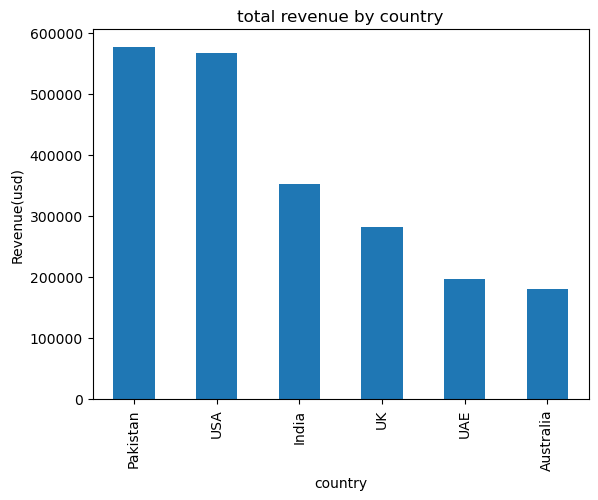

In [17]:
df.groupby('country')['revenue_usd'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('total revenue by country')
plt.ylabel('Revenue(usd)')
plt.show()

## Revenue by Menu Item
Identifying which menu items generate the most revenue. "Combo/Multiple" is excluded from the chart as it is a bundled category roughly 20x larger than any individual item, which would otherwise make the chart unreadable.

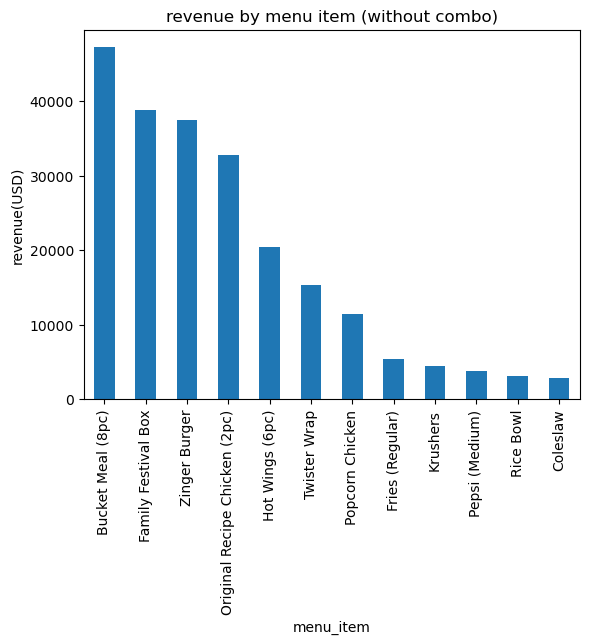

In [21]:
df.groupby('menu_item')['revenue_usd'].sum().sort_values(ascending=False).drop('Combo/Multiple').plot(kind='bar')
plt.title('revenue by menu item (without combo)')
plt.ylabel('revenue(USD)')
plt.show()

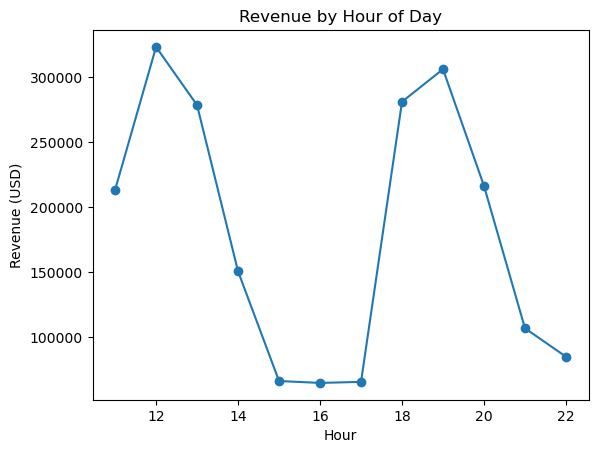

In [20]:
df.groupby('hour')['revenue_usd'].sum().sort_index().plot(kind='line', marker='o') 
plt.title('Revenue by Hour of Day') 
plt.xlabel('Hour') 
plt.ylabel('Revenue (USD)') 
plt.show()

C:\Users\PMLS\AppData\Local\Temp\ipykernel_40524\4256283064.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day_of_week')['revenue_usd'].sum().plot(kind='bar')


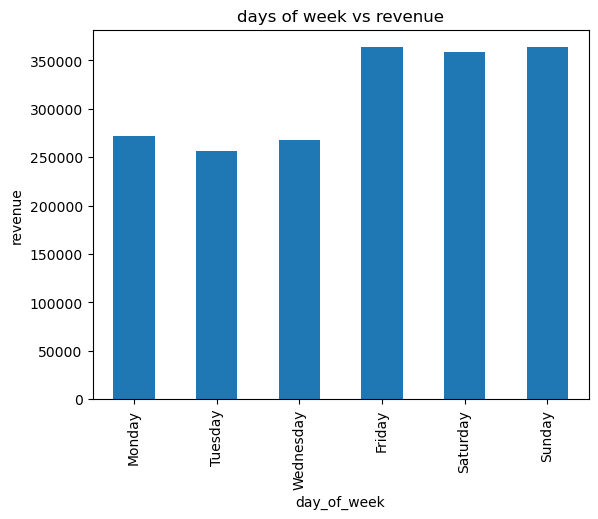

In [35]:
df.groupby('day_of_week')['revenue_usd'].sum().plot(kind='bar')
plt.title("days of week vs revenue")
plt.ylabel("revenue")
plt.show()

In [34]:
day_order=['Monday','Tuesday','Wednesday','Friday','Saturday','Sunday']
df['day_of_week']=pd.Categorical(df['day_of_week'],categories=day_order,ordered=True)

In [36]:
pd.pivot_table(df,values='revenue_usd',index='country',columns='channel',aggfunc='sum')

channel,Delivery,Dine-In,Drive-Thru,Takeaway
country,,,,
Australia,38474.00,62023.87,36599.75,43795.30
India,76634.95,122668.35,68561.74,83883.37
Pakistan,122342.81,200135.36,113787.10,140594.56
UAE,40877.66,69304.42,39265.01,47743.64
UK,59260.68,98772.81,56189.85,67081.62
USA,122334.83,196115.12,111043.09,138390.27


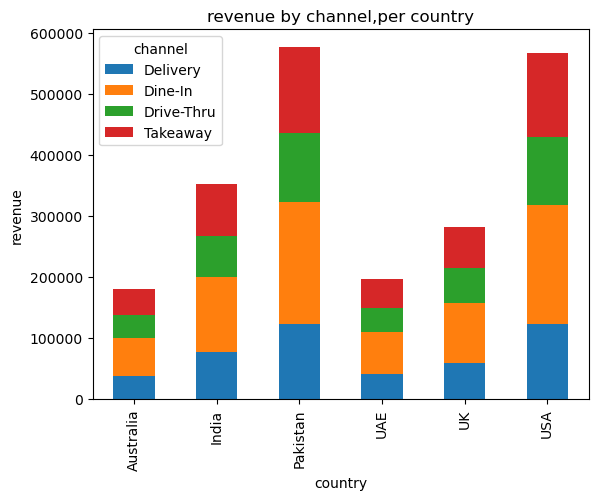

In [38]:
pd.pivot_table(df,values='revenue_usd',index='country',columns='channel',aggfunc='sum').plot(kind='bar',stacked=True)
plt.title('revenue by channel,per country')
plt.ylabel('revenue')
plt.legend(title='channel')
plt.show()

## Statistical Analysis
Going beyond visual comparison: checking the distribution of transaction revenue, the correlation between order size and revenue, and testing whether the country-level revenue differences are statistically meaningful.

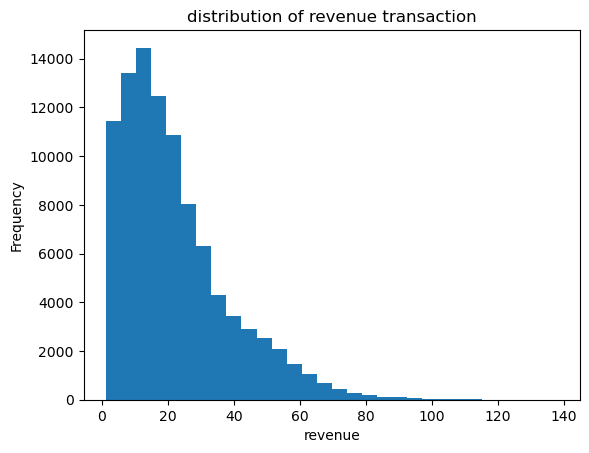

In [39]:
df['revenue_usd'].plot(kind='hist',bins=30)
plt.title('distribution of revenue transaction')
plt.xlabel('revenue')
plt.show()

In [42]:
print('mean:', df['revenue_usd'].mean())
print('median:',df['revenue_usd'].median())
print('stdv:',df['revenue_usd'].std())

mean: 22.285763195435095
median: 18.1
stdv: 16.352702628358983


In [43]:
df[['items_count','revenue_usd']].corr()

,items_count,revenue_usd
items_count,1.000000,0.660664
revenue_usd,0.660664,1.000000


In [45]:
!pip install scipy
from scipy import stats
Pakistan=df[df['country']=='Pakistan']['revenue_usd']
USA=df[df['country']=='USA']['revenue_usd']
t_stat,p_value=stats.ttest_ind(Pakistan,USA)
print('P-value:',p_value)

P-value: 0.6450075507312183


## Conclusions

- **Revenue by country is driven by transaction volume, not spending behavior.** Pakistan and USA lead in total revenue mainly because they have the most transactions (25,909 and 25,430 respectively) — not because customers there spend more. Average revenue per transaction is nearly identical across all six countries (22.17–22.44 USD), and a t-test comparing Pakistan and USA confirmed this difference is not statistically significant (p = 0.645).
- **Bucket Meal (8pc) is the top individual seller**, followed by Family Festival Box and Zinger Burger, once the bundled "Combo/Multiple" category is excluded.
- **Dine-In is the strongest channel** by revenue, with a consistent channel mix (Dine-In > Delivery/Takeaway > Drive-Thru) across every country — suggesting channel preference doesn't vary much by market, even though total revenue does.
- **Sales follow a clear two-peak daily pattern**, spiking around lunch (12:00) and dinner (18:00–19:00), with a sharp lull in the mid-afternoon (14:00–17:00) — a pattern useful for staffing and promotion timing.
- **Order size and revenue are moderately correlated (0.66)**, meaning larger orders tend to generate more revenue, but the relationship isn't perfect — other factors like item mix and discounts also play a role. This is a correlation, not evidence of causation.

**Tools used:** Python (pandas, matplotlib, scipy) in Jupyter Notebook.